In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

products    = pd.read_csv('../data/products.csv')
returns     = pd.read_csv('../data/returns.csv',    parse_dates=['return_date'])
reviews     = pd.read_csv('../data/reviews.csv',    parse_dates=['review_date'])
order_items = pd.read_csv('../data/order_items.csv', low_memory=False)
orders      = pd.read_csv('../data/orders.csv',     parse_dates=['order_date'])
customers   = pd.read_csv('../data/customers.csv')
shipments   = pd.read_csv('../data/shipments.csv',  parse_dates=['ship_date', 'delivery_date'])
payments    = pd.read_csv('../data/payments.csv')
promotions  = pd.read_csv('../data/promotions.csv', parse_dates=['start_date', 'end_date'])
print("Data loaded.")

Data loaded.


In [37]:
# Item-level tables
sales_items    = order_items.merge(products[['product_id','product_name','category','size']], on='product_id', how='left')
returned_items = returns.merge(   products[['product_id','product_name','category','size']], on='product_id', how='left')

# Order-level analysis table
shipments['delivery_time_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days

order_analysis = (
    orders[['order_id','order_date','customer_id']]
    .merge(shipments[['order_id','delivery_time_days','shipping_fee']], on='order_id', how='left')
    .merge(payments[['order_id','payment_value','installments','payment_method']],  on='order_id', how='left')
    .merge(customers[['customer_id','age_group','gender','acquisition_channel']],   on='customer_id', how='left')
)
order_return = returns.groupby('order_id')['return_quantity'].sum().reset_index()
order_return['is_returned'] = 1
order_review = reviews.groupby('order_id')['rating'].mean().reset_index()
order_promo  = order_items.groupby('order_id')['promo_id'].apply(lambda x: x.notna().any()).reset_index(name='has_promotion')

order_analysis = (order_analysis
    .merge(order_return[['order_id','is_returned']], on='order_id', how='left')
    .merge(order_review, on='order_id', how='left')
    .merge(order_promo,  on='order_id', how='left'))
order_analysis['is_returned']   = order_analysis['is_returned'].fillna(0)
order_analysis['has_promotion'] = order_analysis['has_promotion'].fillna(False).astype(float)

print(f"Tổng đơn hàng  : {orders['order_id'].nunique():,}")
print(f"Đơn có return  : {returns['order_id'].nunique():,}  ({returns['order_id'].nunique()/orders['order_id'].nunique()*100:.1f}%)")
print(f"Rating TB      : {reviews['rating'].mean():.2f} / 5.0")
print(f"Các lý do return   : {sorted(returns['return_reason'].dropna().unique())}")
print(f"Các category sản phẩm: {sorted(products['category'].unique())}")

Tổng đơn hàng  : 646,945
Đơn có return  : 36,062  (5.6%)
Rating TB      : 3.94 / 5.0
Các lý do return   : ['changed_mind', 'defective', 'late_delivery', 'not_as_described', 'wrong_size']
Các category sản phẩm: ['Casual', 'GenZ', 'Outdoor', 'Streetwear']


---
## 1. DESCRIPTIVE ANALYTICS
> Mô tả tổng quan dữ liệu: tỷ lệ trả hàng, phân bổ theo danh mục, size và đánh giá khách hàng.

### Return Rate theo Category
So sánh tỷ lệ trả hàng giữa các danh mục sản phẩm, phân rã theo Age Group và Payment Method.

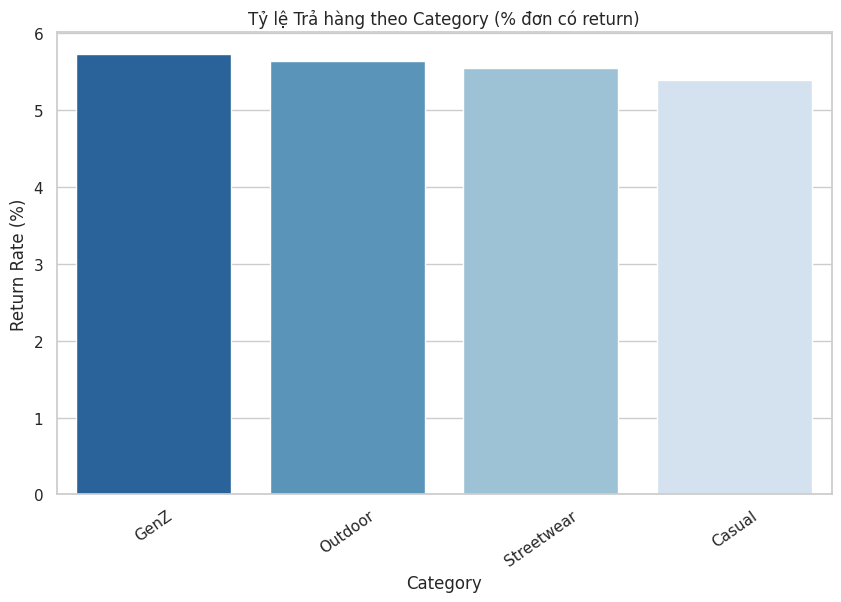

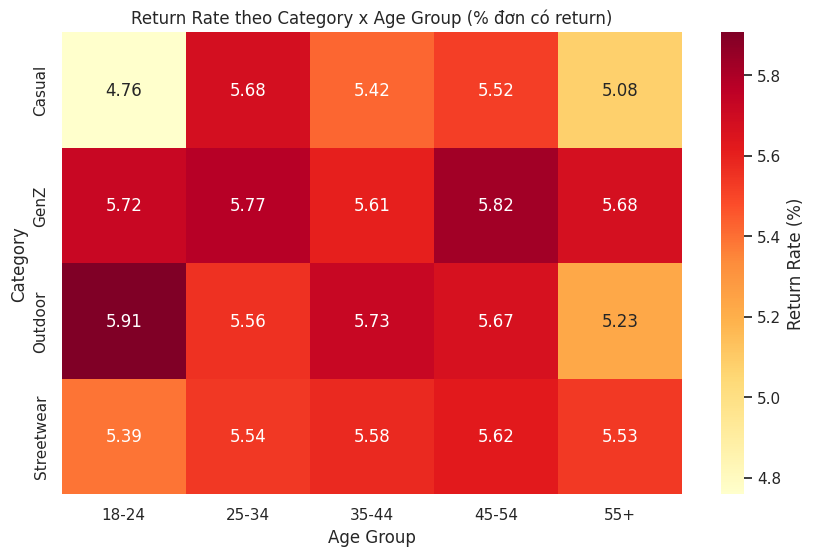

In [50]:
# Return Rate theo SO DON (khong phai theo quantity)
# 1) Tao bang order-category de tinh return rate theo danh muc
order_cat = order_items[['order_id', 'product_id']].merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)
order_cat = order_cat[['order_id', 'category']].drop_duplicates()

# 2) Danh dau don co return
returned_orders = returns[['order_id']].drop_duplicates().assign(is_returned=1)
order_cat = order_cat.merge(returned_orders, on='order_id', how='left')
order_cat['is_returned'] = order_cat['is_returned'].fillna(0)

# 3) Return rate theo category (order-based)
cat_return_rate = order_cat.groupby('category', as_index=False)['is_returned'].mean()
cat_return_rate['return_rate_pct'] = cat_return_rate['is_returned'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(
    data=cat_return_rate.sort_values('return_rate_pct', ascending=False),
    x='category',
    y='return_rate_pct',
    hue='category',
    palette='Blues_r',
    legend=False
)
plt.title('Tỷ lệ Trả hàng theo Category (% đơn có return)')
plt.ylabel('Return Rate (%)')
plt.xlabel('Category')
plt.xticks(rotation=35)
plt.show()

# 4) Lat cat sau: Category x Age Group
order_cat_age = order_cat.merge(
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='left'
).merge(
    customers[['customer_id', 'age_group']],
    on='customer_id',
    how='left'
)

cat_age_rate = order_cat_age.groupby(['category', 'age_group'], as_index=False)['is_returned'].mean()
cat_age_rate['return_rate_pct'] = cat_age_rate['is_returned'] * 100
pivot_cat_age = cat_age_rate.pivot(index='category', columns='age_group', values='return_rate_pct')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_cat_age, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Return Rate (%)'})
plt.title('Return Rate theo Category x Age Group (% đơn có return)')
plt.xlabel('Age Group')
plt.ylabel('Category')
plt.show()




### Return Rate theo Size
So sánh tỷ lệ trả hàng theo từng kích cỡ sản phẩm.

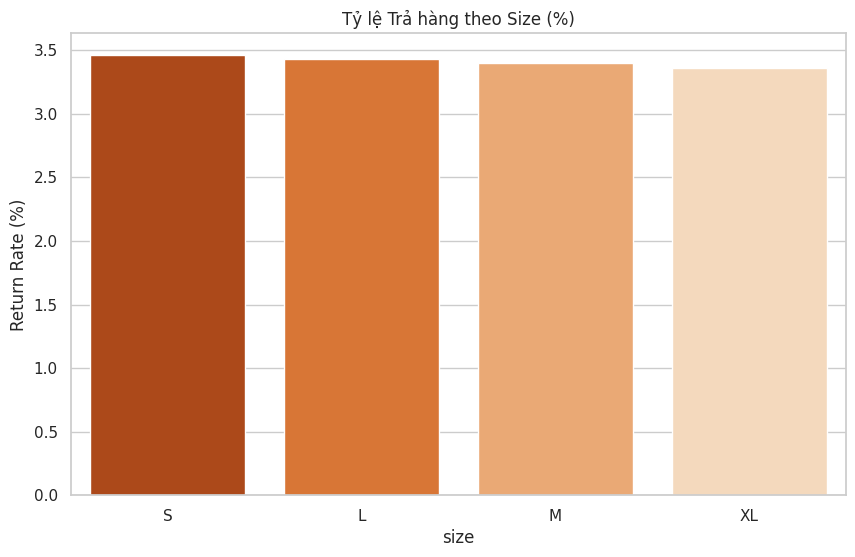

In [39]:
sales_by_size = sales_items.groupby('size')['quantity'].sum().reset_index(name='total_sold')
returns_by_size = returned_items.groupby('size')['return_quantity'].sum().reset_index(name='total_returned')

size_return_rate = sales_by_size.merge(returns_by_size, on='size', how='left').fillna(0)
size_return_rate['return_rate_pct'] = (size_return_rate['total_returned'] / size_return_rate['total_sold']) * 100

plt.figure()
sns.barplot(data=size_return_rate.sort_values('return_rate_pct', ascending=False), x='size', y='return_rate_pct', palette='Oranges_r')
plt.title('Tỷ lệ Trả hàng theo Size (%)')
plt.ylabel('Return Rate (%)')
plt.show()

### Return Rate theo Size × Category và Size × Age Group
Phân rã tỷ lệ trả hàng theo size kết hợp với danh mục sản phẩm và nhóm tuổi khách hàng.

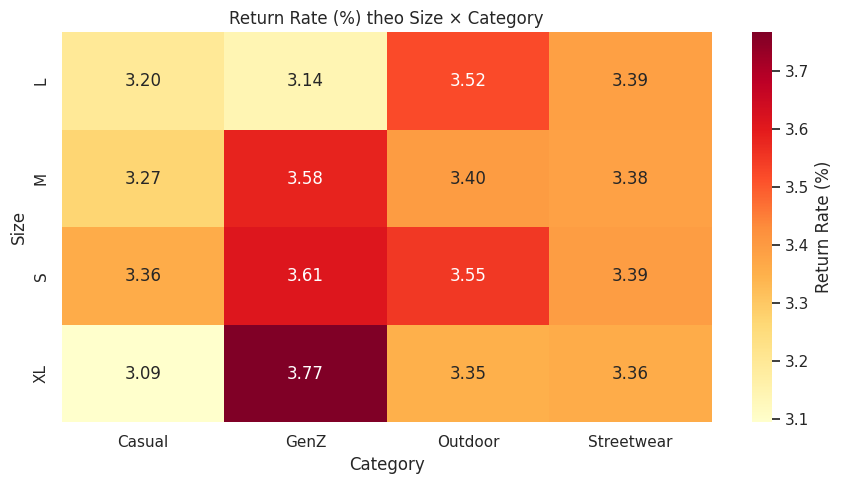

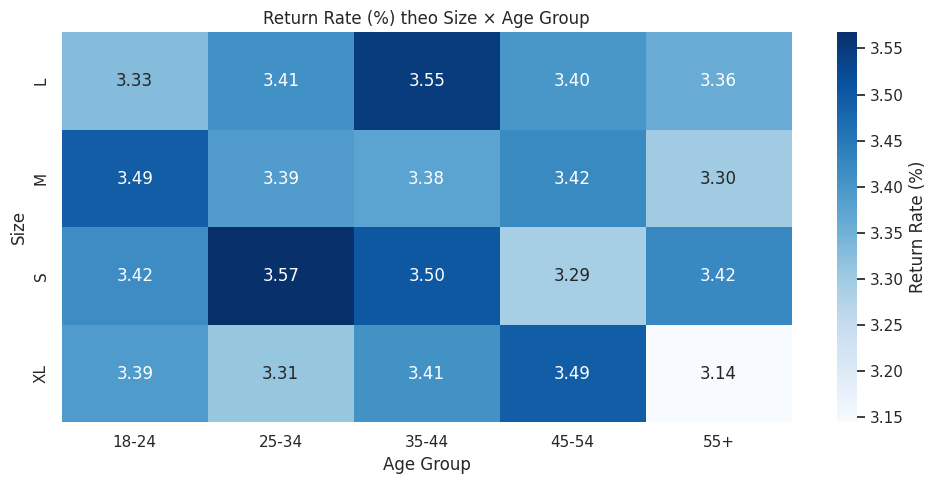

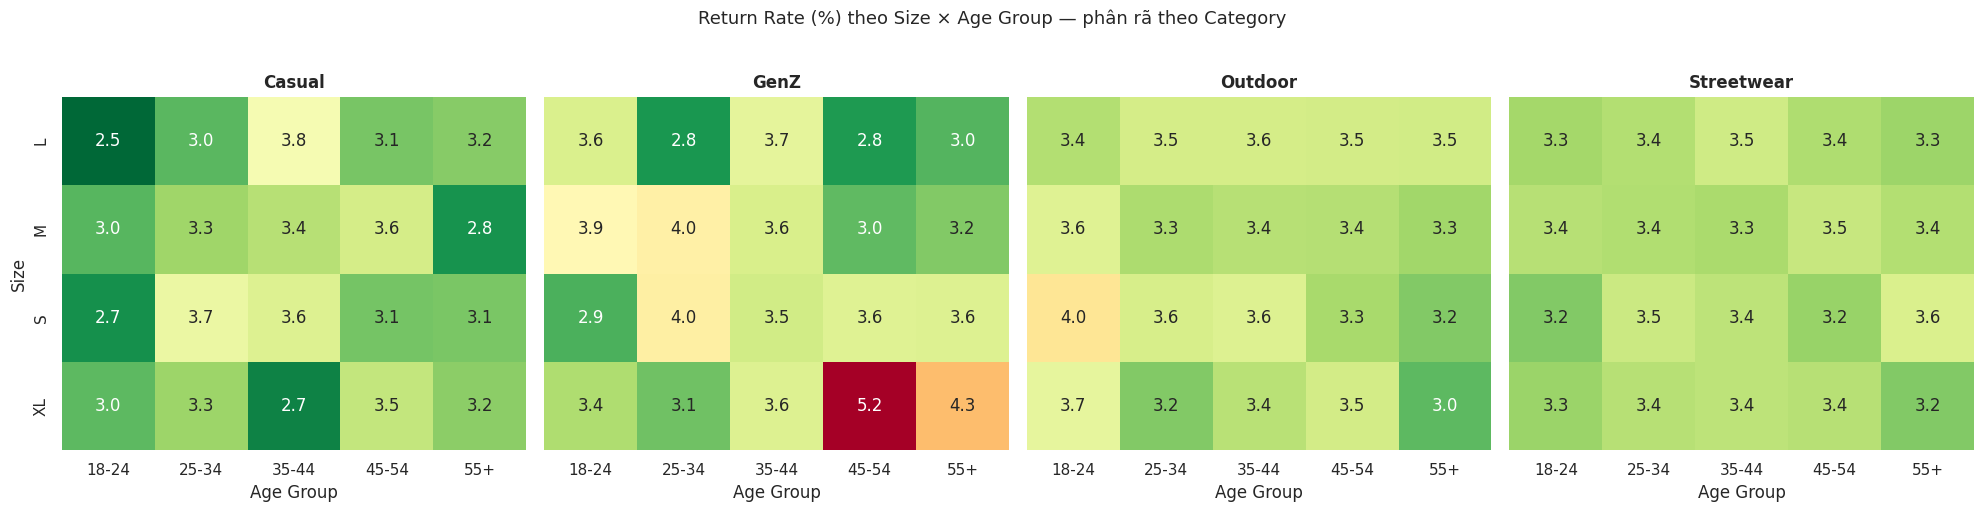

In [49]:
# ── Chuẩn bị dữ liệu ─────────────────────────────────────────────────────────
# Gắn age_group vào returned_items qua orders → customers
ret_detail = (
    returns
    .merge(orders[['order_id','customer_id']], on='order_id', how='left')
    .merge(customers[['customer_id','age_group']],   on='customer_id', how='left')
    .merge(products[['product_id','category','size']], on='product_id', how='left')
)
sales_detail = (
    order_items
    .merge(orders[['order_id','customer_id']], on='order_id', how='left')
    .merge(customers[['customer_id','age_group']],    on='customer_id', how='left')
    .merge(products[['product_id','category','size']], on='product_id', how='left')
)

def return_rate(sales_grp, ret_grp, keys):
    s = sales_detail.groupby(keys)['quantity'].sum().rename('sold')
    r = ret_detail.groupby(keys)['return_quantity'].sum().rename('returned')
    df = pd.concat([s, r], axis=1).fillna(0).reset_index()
    df['rate'] = df['returned'] / df['sold'] * 100
    return df

# ── Chart 1: Heatmap Size × Category ─────────────────────────────────────────
sc = return_rate(sales_detail, ret_detail, ['size','category'])
pivot_sc = sc.pivot(index='size', columns='category', values='rate')

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_sc, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Return Rate (%)'})
plt.title('Return Rate (%) theo Size × Category')
plt.xlabel('Category')
plt.ylabel('Size')
plt.tight_layout()
plt.show()

# ── Chart 2: Heatmap Size × Age Group ────────────────────────────────────────
sa = return_rate(sales_detail, ret_detail, ['size','age_group'])
pivot_sa = sa.pivot(index='size', columns='age_group', values='rate')

# Sắp xếp age_group theo thứ tự tự nhiên
age_order = [c for c in ['18-24','25-34','35-44','45-54','55+'] if c in pivot_sa.columns]
pivot_sa = pivot_sa[age_order]

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_sa, annot=True, fmt='.2f', cmap='Blues',
            cbar_kws={'label': 'Return Rate (%)'})
plt.title('Return Rate (%) theo Size × Age Group')
plt.xlabel('Age Group')
plt.ylabel('Size')
plt.tight_layout()
plt.show()

# ── Chart 3: Facet — Return Rate theo Size, phân rã theo Category × Age Group
sca = return_rate(sales_detail, ret_detail, ['category','age_group','size'])
age_order_full = [a for a in ['18-24','25-34','35-44','45-54','55+'] if a in sca['age_group'].unique()]
sca['age_group'] = pd.Categorical(sca['age_group'], categories=age_order_full, ordered=True)
sca = sca.sort_values(['category','age_group'])

cats = sorted(sca['category'].unique())
fig, axes = plt.subplots(1, len(cats), figsize=(5*len(cats), 5), sharey=True)
if len(cats) == 1:
    axes = [axes]

for ax, cat in zip(axes, cats):
    sub = sca[sca['category'] == cat].pivot(index='size', columns='age_group', values='rate')
    sub = sub[[c for c in age_order_full if c in sub.columns]]
    sns.heatmap(sub, annot=True, fmt='.1f', cmap='RdYlGn_r',
                cbar=False, ax=ax, vmin=sca['rate'].min(), vmax=sca['rate'].max())
    ax.set_title(cat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Size' if cat == cats[0] else '')

fig.suptitle('Return Rate (%) theo Size × Age Group — phân rã theo Category', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Phân bổ Rating và Rating trung bình theo Nhóm tuổi & Giới tính
Phân phối sao đánh giá tổng thể và so sánh trung bình theo phân khúc khách hàng.

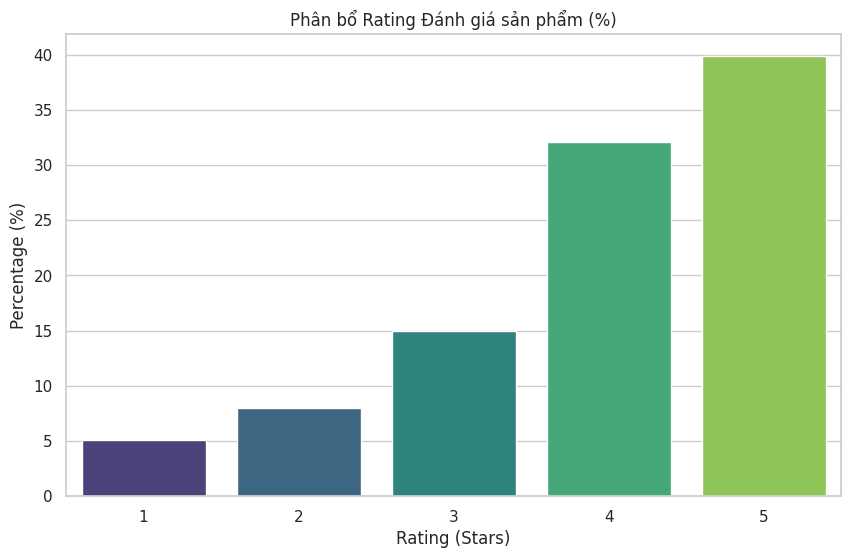

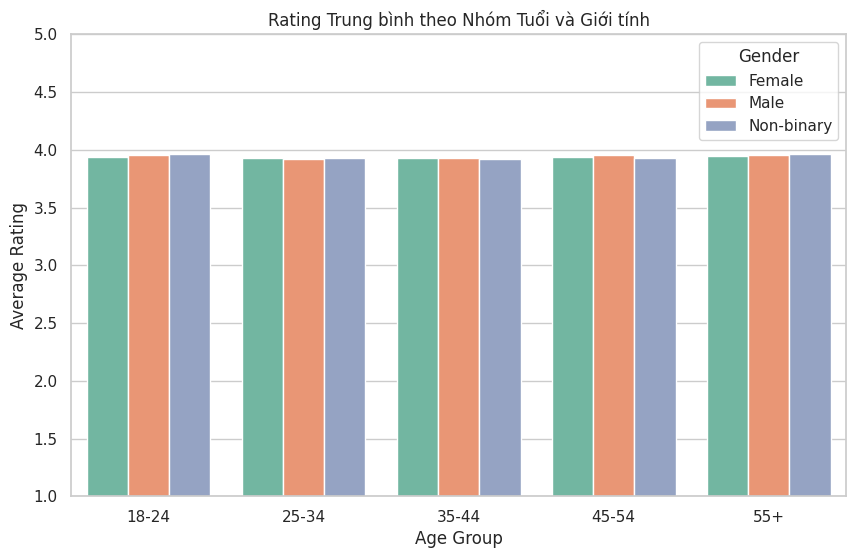

In [40]:
# 1) Phân bổ Rating tổng quan
plt.figure()
rating_counts = reviews['rating'].value_counts(normalize=True).sort_index() * 100
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.title('Phân bổ Rating Đánh giá sản phẩm (%)')
plt.xlabel('Rating (Stars)')
plt.ylabel('Percentage (%)')
plt.show()

# 2) Phân tích sâu: Rating trung bình theo nhóm khách hàng
# reviews đã có customer_id, vì vậy không merge thêm customer_id từ orders để tránh trùng cột
reviews_customer = reviews.copy()
reviews_customer = reviews_customer.merge(
    customers[['customer_id', 'age_group', 'gender']],
    on='customer_id',
    how='left'
)

rating_demo = reviews_customer.groupby(['age_group', 'gender'])['rating'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=rating_demo, x='age_group', y='rating', hue='gender', palette='Set2')
plt.title('Rating Trung bình theo Nhóm Tuổi và Giới tính')
plt.xlabel('Age Group')
plt.ylabel('Average Rating')
plt.ylim(1, 5)
plt.legend(title='Gender')
plt.show()

---
## 2. DIAGNOSTIC ANALYTICS
> Phân tích nguyên nhân: lý do trả hàng, tác động của vận chuyển, khuyến mãi và phương thức thanh toán.

### Phân bổ Lý do Trả hàng theo Age Group
Tỷ trọng các lý do trả hàng và mức độ tập trung theo nhóm tuổi.

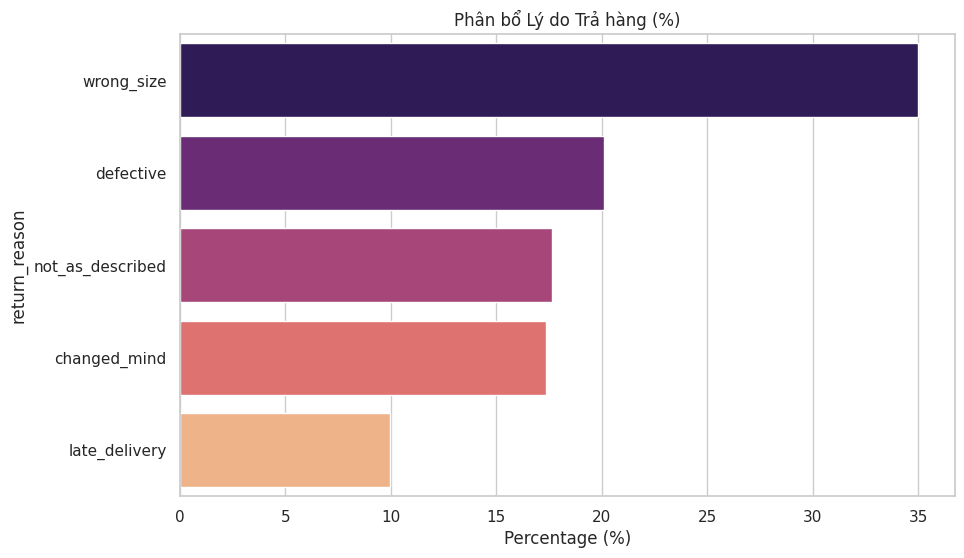

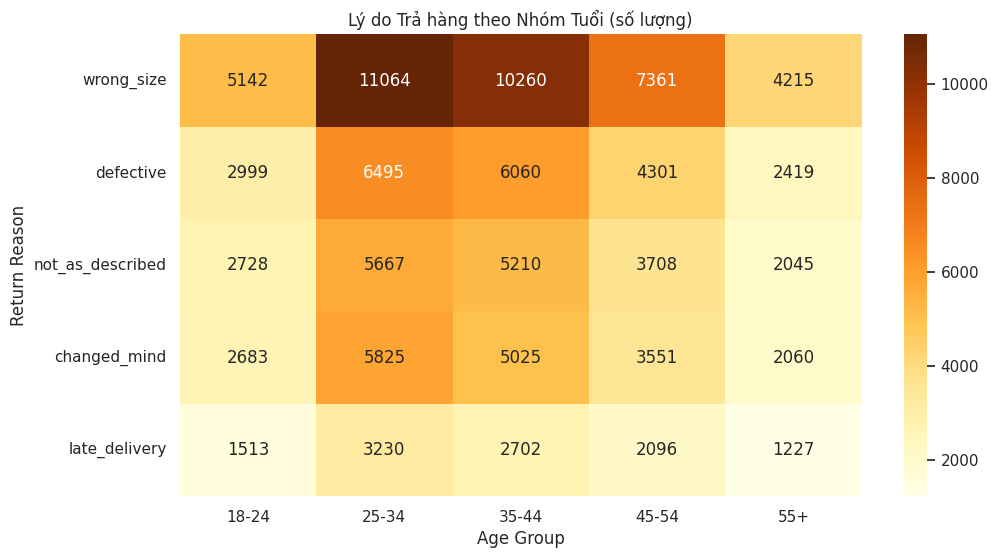

In [41]:
# 1) Phân bổ lý do trả hàng tổng quan
plt.figure()
reason_counts = returns['return_reason'].value_counts(normalize=True) * 100
sns.barplot(x=reason_counts.values, y=reason_counts.index, palette='magma')
plt.title('Phân bổ Lý do Trả hàng (%)')
plt.xlabel('Percentage (%)')
plt.show()

# 2) Phân tích sâu: Lý do trả hàng khác nhau theo nhóm tuổi
returns_with_customer = returns.merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
returns_with_customer = returns_with_customer.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')

reason_age = returns_with_customer.pivot_table(
    index='return_reason',
    columns='age_group',
    values='return_quantity',
    aggfunc='sum',
    fill_value=0
)

# Chỉ giữ top 8 lý do để biểu đồ dễ đọc
top_reason_idx = reason_age.sum(axis=1).sort_values(ascending=False).head(8).index
reason_age_top = reason_age.loc[top_reason_idx]

plt.figure(figsize=(11, 6))
sns.heatmap(reason_age_top, annot=True, fmt='.0f', cmap='YlOrBr')
plt.title('Lý do Trả hàng theo Nhóm Tuổi (số lượng)')
plt.ylabel('Return Reason')
plt.xlabel('Age Group')
plt.show()

### So sánh Rating: Đơn Có Return vs Không Return
Boxplot rating và tỷ lệ low-rating (≤ 2 sao) giữa đơn bị trả và không bị trả.

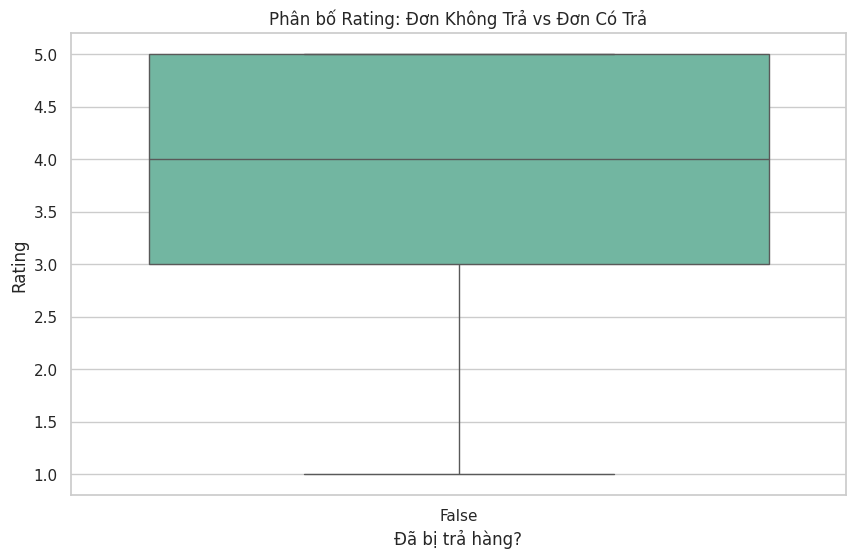

Điểm rating trung bình theo return flag:
is_returned
False    3.936011
Name: rating, dtype: float64


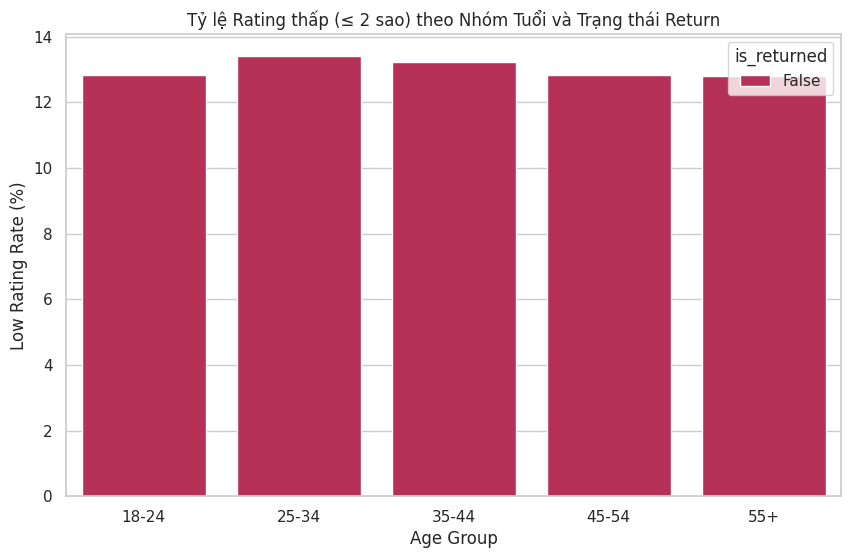

In [42]:
# Đánh dấu đơn có return để so sánh rating
returns_item = returns[['order_id', 'product_id']].drop_duplicates().assign(return_item_flag=True)
returns_order = returns[['order_id']].drop_duplicates().assign(return_order_flag=True)

reviews_orders = reviews.merge(returns_item, on=['order_id', 'product_id'], how='left')
reviews_orders = reviews_orders.merge(returns_order, on='order_id', how='left')

reviews_orders['is_returned'] = (
    reviews_orders['return_item_flag'].fillna(False) |
    reviews_orders['return_order_flag'].fillna(False)
)

reviews_orders = reviews_orders.merge(
    customers[['customer_id', 'age_group', 'acquisition_channel']],
    on='customer_id',
    how='left'
)

# 1) Phân bố rating: đơn có return vs không return
plt.figure()
sns.boxplot(data=reviews_orders, x='is_returned', y='rating', palette='Set2')
plt.title('Phân bố Rating: Đơn Không Trả vs Đơn Có Trả')
plt.xlabel('Đã bị trả hàng?')
plt.ylabel('Rating')
plt.show()

print("Điểm rating trung bình theo return flag:")
print(reviews_orders.groupby('is_returned')['rating'].mean())

# 2) Tỷ lệ low-rating (<=2) theo age_group và trạng thái return
reviews_orders['low_rating_flag'] = (reviews_orders['rating'] <= 2).astype(int)
low_rating_age = reviews_orders.groupby(['age_group', 'is_returned'])['low_rating_flag'].mean().reset_index()
low_rating_age['low_rating_pct'] = low_rating_age['low_rating_flag'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=low_rating_age, x='age_group', y='low_rating_pct', hue='is_returned', palette='rocket')
plt.title('Tỷ lệ Rating thấp (≤ 2 sao) theo Nhóm Tuổi và Trạng thái Return')
plt.xlabel('Age Group')
plt.ylabel('Low Rating Rate (%)')
plt.legend(title='is_returned')
plt.show()

### Hàng Lỗi (Defective) tập trung theo Category
Số lượng sản phẩm bị trả do lỗi kỹ thuật phân bổ theo danh mục.

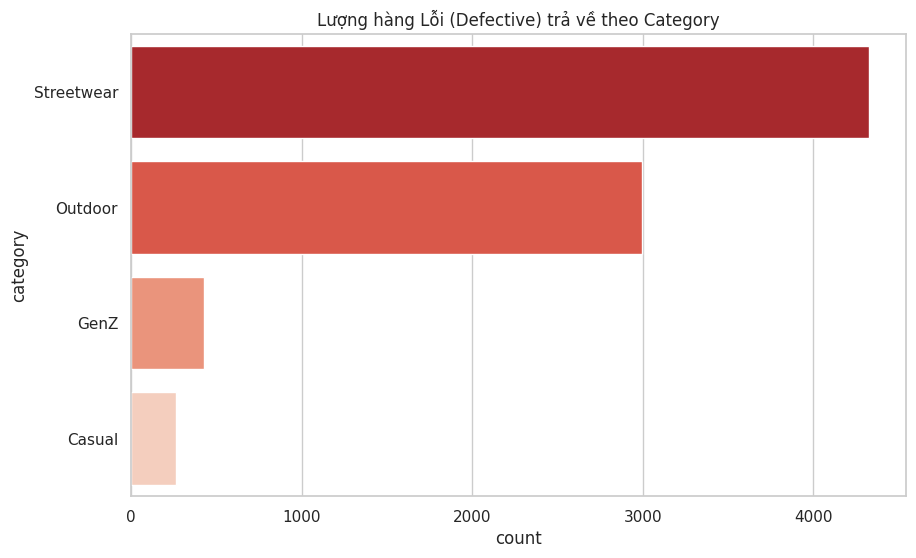

Các lý do trả hàng thực tế trong dữ liệu:
<StringArray>
['late_delivery', 'wrong_size', 'defective', 'changed_mind',
 'not_as_described']
Length: 5, dtype: str


In [43]:
defective_returns = returned_items[returned_items['return_reason'].str.contains('defect', case=False, na=False) | 
                                   (returned_items['return_reason'] == 'Lỗi kỹ thuật') |  
                                   (returned_items['return_reason'] == 'Hỏng hóc') ] 

# Lấy top category có số lượng lỗi cao nhất
if len(defective_returns) > 0:
    plt.figure()
    sns.countplot(data=defective_returns, y='category', order=defective_returns['category'].value_counts().index, palette='Reds_r')
    plt.title('Lượng hàng Lỗi (Defective) trả về theo Category')
    plt.show()
else:
    print("Không thấy label rõ ràng cho 'Defect' hoặc số lượng quá ít, hãy trực tiếp xem bảng lý do trả hàng bên trên.")

# Gợi ý: check keyword defective thực tế trong data returns
print("Các lý do trả hàng thực tế trong dữ liệu:")
print(returns['return_reason'].unique())

### Top 10 Sản phẩm Rủi ro Return cao nhất
Top 10 sản phẩm có return rate cao nhất trong nhóm đã bán từ 30 lượt trở lên.

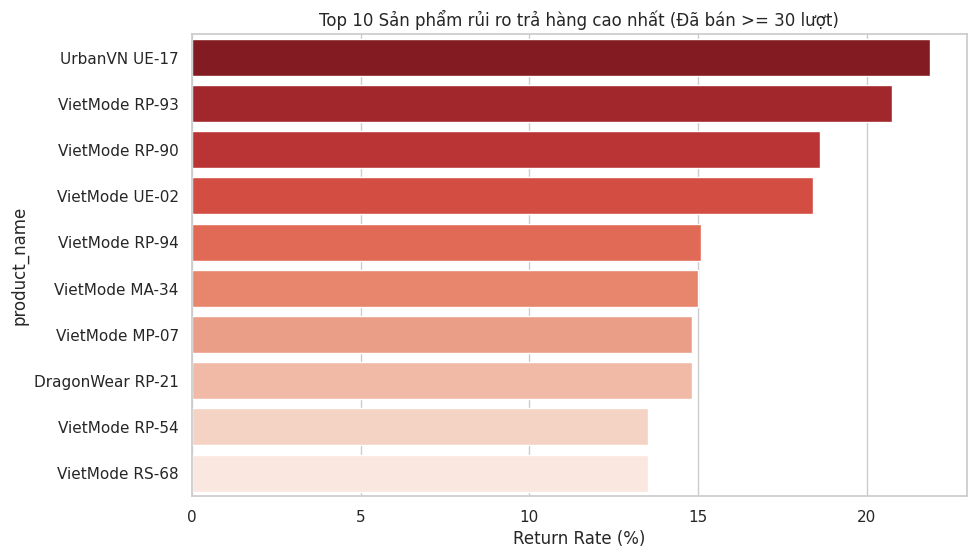

In [44]:
# Sản phẩm nào có tỷ lệ return cao nhất? (lọc các SP có volume bán đủ lớn)
sales_by_prod = sales_items.groupby(['product_id', 'product_name', 'category'])['quantity'].sum().reset_index(name='total_sold')
returns_by_prod = returned_items.groupby('product_id')['return_quantity'].sum().reset_index(name='total_returned')

prod_risk = sales_by_prod.merge(returns_by_prod, on='product_id', how='left').fillna(0)
prod_risk['return_rate_pct'] = (prod_risk['total_returned'] / prod_risk['total_sold']) * 100

high_volume_prods = prod_risk[prod_risk['total_sold'] >= 30].copy()
top_risk_prods = high_volume_prods.sort_values('return_rate_pct', ascending=False).head(10)

plt.figure()
sns.barplot(data=top_risk_prods, y='product_name', x='return_rate_pct', palette='Reds_r')
plt.title('Top 10 Sản phẩm rủi ro trả hàng cao nhất (Đã bán >= 30 lượt)')
plt.xlabel('Return Rate (%)')
plt.show()

### Ma trận Tương quan: Vận chuyển, Khuyến mãi, Thanh toán vs Trải nghiệm
Mức tương quan tuyến tính giữa các biến vận hành và chỉ số trải nghiệm khách hàng.

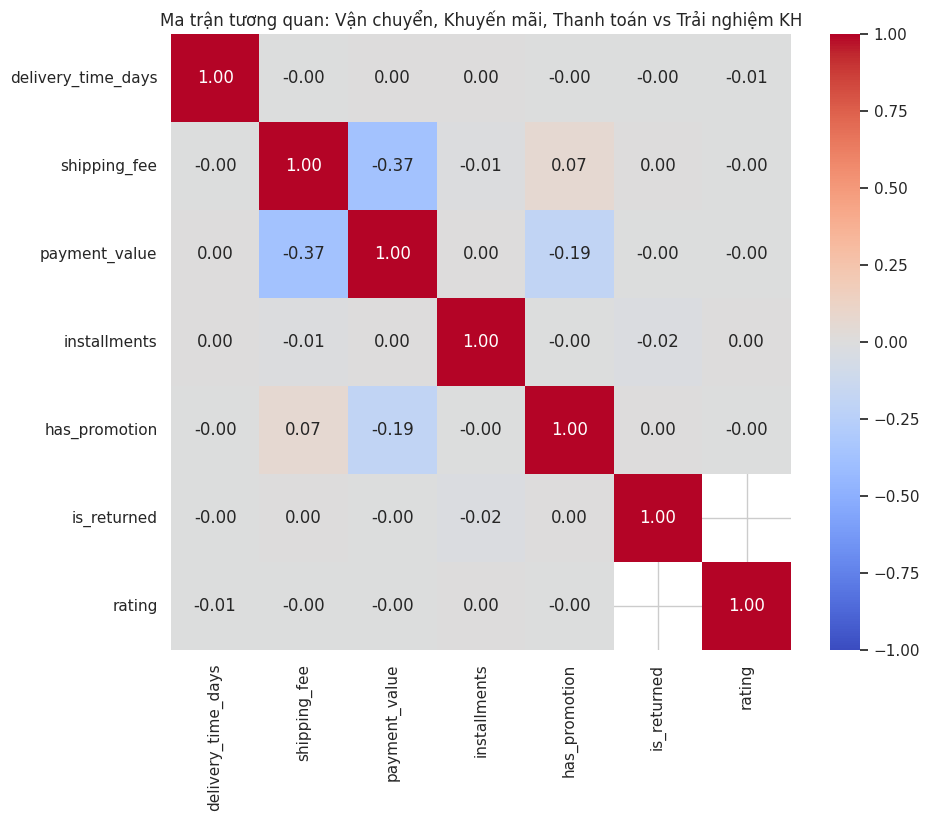

In [45]:
# Tính ma trận tương quan (chỉ lấy các biến số (numeric))
corr_cols = ['delivery_time_days', 'shipping_fee', 'payment_value', 'installments', 'has_promotion', 'is_returned', 'rating']
corr_matrix = order_analysis[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", center=0)
plt.title('Ma trận tương quan: Vận chuyển, Khuyến mãi, Thanh toán vs Trải nghiệm KH')
plt.show()

### Thời gian Giao hàng ảnh hưởng đến Rating?
Phân bố delivery time theo từng mức rating để kiểm tra tác động của SLA giao hàng.

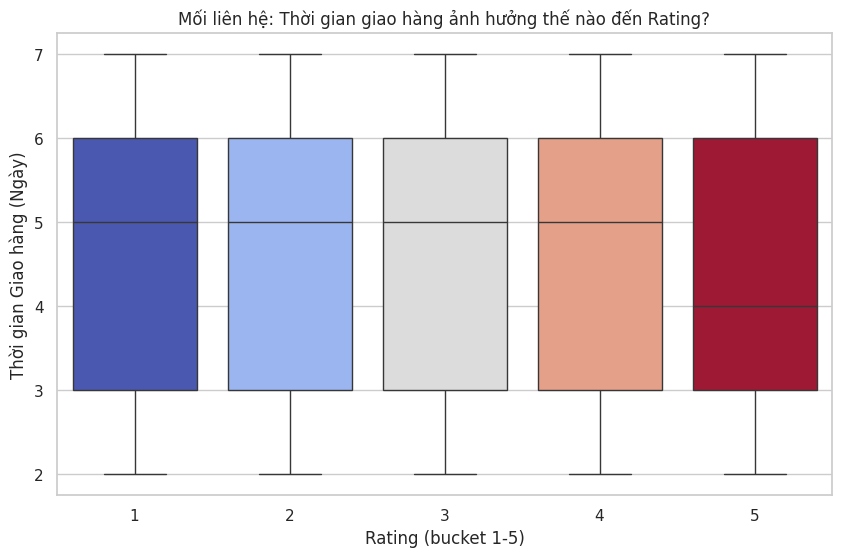

In [46]:
# Trực quan cụ thể 1: Thời gian giao hàng có làm suy giảm Rating không?
plot_df = order_analysis[['rating', 'delivery_time_days']].dropna().copy()
plot_df['rating_bucket'] = plot_df['rating'].round().clip(1, 5).astype(int)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=plot_df,
    x='rating_bucket',
    y='delivery_time_days',
    hue='rating_bucket',
    dodge=False,
    palette='coolwarm',
    legend=False
)
plt.title('Mối liên hệ: Thời gian giao hàng ảnh hưởng thế nào đến Rating?')
plt.xlabel('Rating (bucket 1-5)')
plt.ylabel('Thời gian Giao hàng (Ngày)')
plt.show()

### Khuyến mãi có làm tăng tỷ lệ Đổi trả không?
So sánh return rate giữa đơn có và không có promotion, phân rã theo nhóm tuổi.

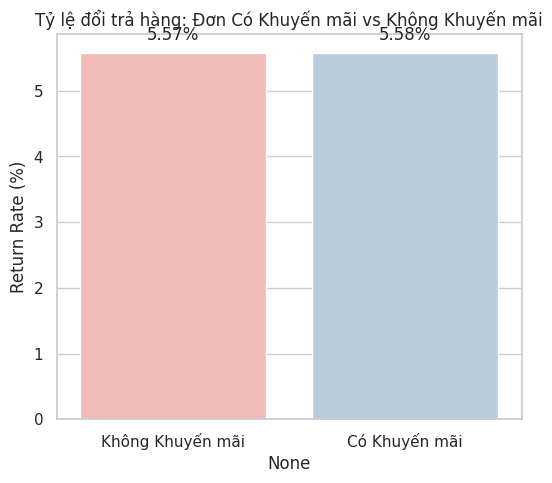

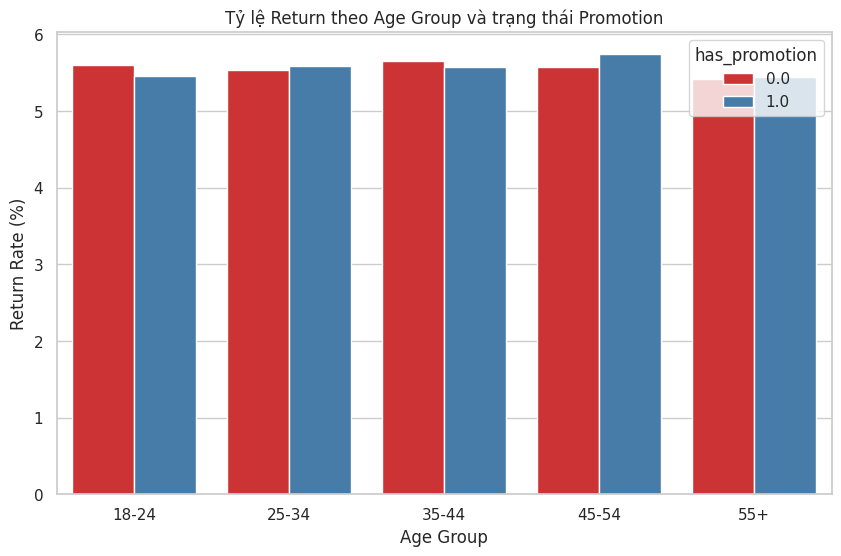

In [47]:
# Trực quan cụ thể 2: Có Khuyến mãi thì tỷ lệ đổi trả (Return) có bị thay đổi không?
promo_return_rate = order_analysis.groupby('has_promotion')['is_returned'].mean() * 100
promo_return_rate.index = ['Không Khuyến mãi', 'Có Khuyến mãi']

plt.figure(figsize=(6, 5))
sns.barplot(x=promo_return_rate.index, y=promo_return_rate.values, palette='Pastel1')
plt.title('Tỷ lệ đổi trả hàng: Đơn Có Khuyến mãi vs Không Khuyến mãi')
plt.ylabel('Return Rate (%)')
for i, v in enumerate(promo_return_rate.values):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center', fontsize=12)
plt.show()

# Phân tích sâu: tác động promotion theo từng nhóm tuổi
promo_age = order_analysis.groupby(['age_group', 'has_promotion'])['is_returned'].mean().reset_index()
promo_age['return_rate_pct'] = promo_age['is_returned'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=promo_age, x='age_group', y='return_rate_pct', hue='has_promotion', palette='Set1')
plt.title('Tỷ lệ Return theo Age Group và trạng thái Promotion')
plt.xlabel('Age Group')
plt.ylabel('Return Rate (%)')
plt.legend(title='has_promotion')
plt.show()

### Phương thức Thanh toán và Rủi ro Trả hàng
Return rate theo payment method tổng quan và phân rã theo age group.

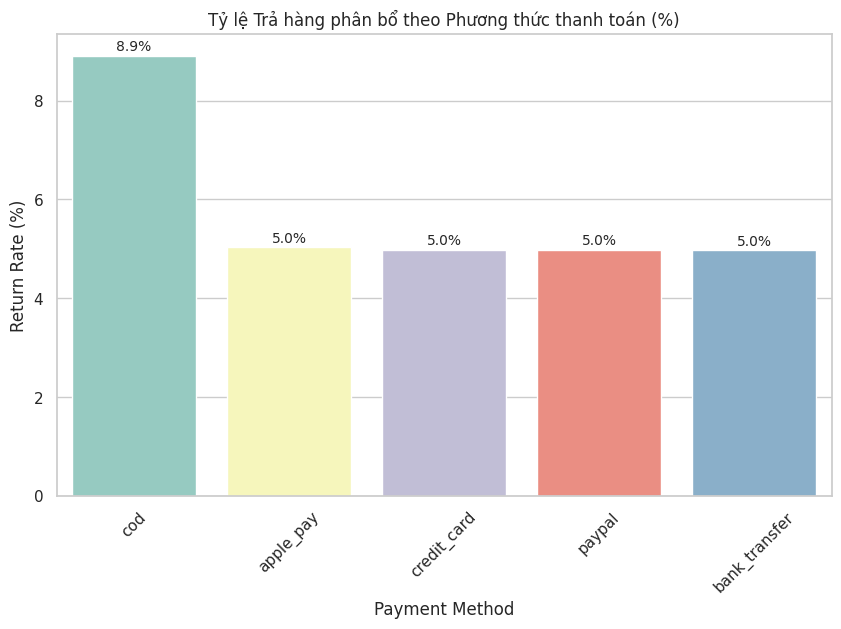

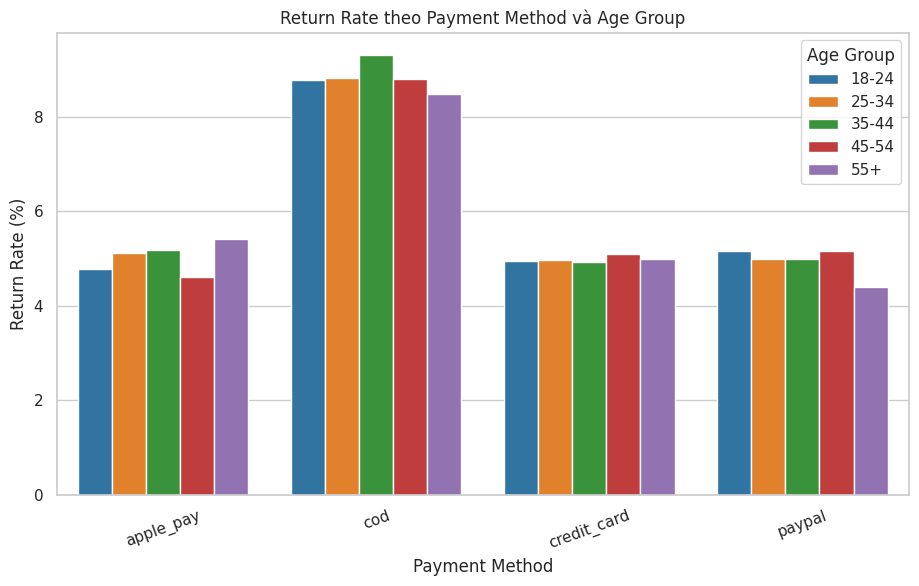

In [48]:
# Trực quan cụ thể 3: Có phương thức thanh toán nào hay gặp rủi ro Return hơn không?
plt.figure()
pay_return_rate = order_analysis.groupby('payment_method')['is_returned'].mean() * 100
pay_return_rate = pay_return_rate.sort_values(ascending=False)

sns.barplot(x=pay_return_rate.index, y=pay_return_rate.values, palette='Set3')
plt.title('Tỷ lệ Trả hàng phân bổ theo Phương thức thanh toán (%)')
plt.ylabel('Return Rate (%)')
plt.xlabel('Payment Method')
for i, v in enumerate(pay_return_rate.values):
    plt.text(i, v + 0.1, f"{v:.1f}%", ha='center', fontsize=10)
plt.xticks(rotation=45)
plt.show()

# Phân tích sâu: payment method x age group
pay_age = order_analysis.groupby(['payment_method', 'age_group'])['is_returned'].mean().reset_index()
pay_age['return_rate_pct'] = pay_age['is_returned'] * 100

# Chỉ giữ top payment method theo số đơn để plot gọn
top_pay_methods = order_analysis['payment_method'].value_counts().head(4).index
pay_age = pay_age[pay_age['payment_method'].isin(top_pay_methods)]

plt.figure(figsize=(11, 6))
sns.barplot(data=pay_age, x='payment_method', y='return_rate_pct', hue='age_group', palette='tab10')
plt.title('Return Rate theo Payment Method và Age Group')
plt.xlabel('Payment Method')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=20)
plt.legend(title='Age Group')
plt.show()

---
## PREDICTIVE ANALYTICS — Mô hình dự báo Return Risk

> Mục tiêu: Dự báo xác suất một đơn hàng bị trả lại, dựa trên các đặc trưng có sẵn tại thời điểm đặt hàng (demographics, vận chuyển, thanh toán, khuyến mãi, category).

In [20]:
# ── 1. Feature Engineering ────────────────────────────────────────────────────
# Lấy dominant category theo đơn (category xuất hiện nhiều lần nhất trong đơn)
order_cat_dom = (
    order_items
    .merge(products[['product_id', 'category']], on='product_id', how='left')
    .groupby('order_id')['category']
    .agg(lambda x: x.mode()[0] if len(x) else None)
    .reset_index(name='main_category')
)

# Tổng số item mỗi đơn
order_item_count = order_items.groupby('order_id')['quantity'].sum().reset_index(name='total_items')

# Cờ promotion (đơn có ít nhất 1 promo)
order_promo2 = order_items.groupby('order_id')['promo_id'].apply(
    lambda x: int(x.notna().any())
).reset_index(name='has_promo')

# Ghép tất cả features về cấp độ Order
feat = (
    orders[['order_id', 'customer_id', 'payment_method', 'device_type', 'order_source']]
    .merge(customers[['customer_id', 'age_group', 'gender', 'acquisition_channel']], on='customer_id', how='left')
    .merge(shipments[['order_id', 'delivery_time_days', 'shipping_fee']], on='order_id', how='left')
    .merge(payments[['order_id', 'payment_value', 'installments']], on='order_id', how='left')
    .merge(order_cat_dom, on='order_id', how='left')
    .merge(order_item_count, on='order_id', how='left')
    .merge(order_promo2, on='order_id', how='left')
)

# Target: đơn có return hay không
returned_order_ids = returns['order_id'].unique()
feat['is_returned'] = feat['order_id'].isin(returned_order_ids).astype(int)

print(f"Dataset: {feat.shape[0]:,} đơn | Return rate: {feat['is_returned'].mean()*100:.1f}%")

# ── 2. Mã hóa categorical features ───────────────────────────────────────────
cat_cols = ['age_group', 'gender', 'acquisition_channel', 'payment_method',
            'device_type', 'order_source', 'main_category']
num_cols = ['delivery_time_days', 'shipping_fee', 'payment_value',
            'installments', 'total_items', 'has_promo']

model_df = feat[cat_cols + num_cols + ['is_returned']].dropna()

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df = model_df.copy()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    le_dict[col] = le

X = model_df[cat_cols + num_cols]
y = model_df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

### Huấn luyện & Đánh giá mô hình (Logistic Regression vs Random Forest)
Confusion matrix và ROC curve so sánh hiệu suất hai mô hình phân loại.


  Logistic Regression
  ROC-AUC: 0.5432
              precision    recall  f1-score   support

Không return       0.94      0.51      0.66    106002
   Có return       0.07      0.56      0.13      7212

    accuracy                           0.51    113214
   macro avg       0.51      0.53      0.39    113214
weighted avg       0.89      0.51      0.63    113214


  Random Forest
  ROC-AUC: 0.5595
              precision    recall  f1-score   support

Không return       0.94      0.83      0.88    106002
   Có return       0.10      0.28      0.15      7212

    accuracy                           0.80    113214
   macro avg       0.52      0.56      0.52    113214
weighted avg       0.89      0.80      0.84    113214



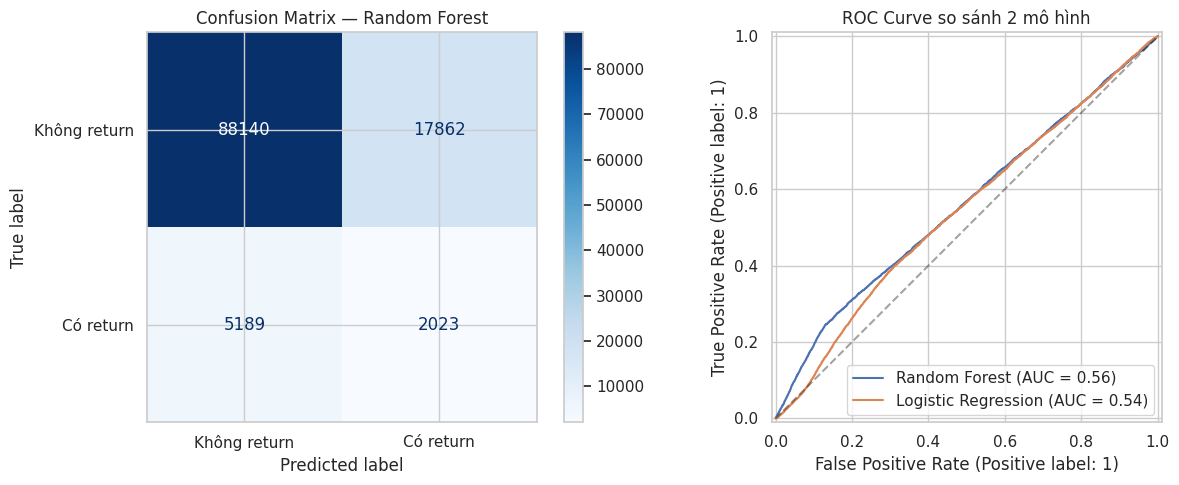

In [21]:
# ── 3. Huấn luyện Logistic Regression & Random Forest ─────────────────────────
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# ── 4. Đánh giá mô hình ───────────────────────────────────────────────────────
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print(classification_report(y_test, y_pred, target_names=['Không return', 'Có return']))

# ── 5. Confusion Matrix + ROC Curve (RF) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test, ax=axes[0], cmap='Blues',
    display_labels=['Không return', 'Có return']
)
axes[0].set_title('Confusion Matrix — Random Forest')

RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[1], name='Random Forest')
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=axes[1], name='Logistic Regression')
axes[1].set_title('ROC Curve so sánh 2 mô hình')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.tight_layout()
plt.show()

### Feature Importance — Yếu tố ảnh hưởng đến Return Risk
Mức độ đóng góp của từng feature vào dự báo trả hàng (Random Forest).

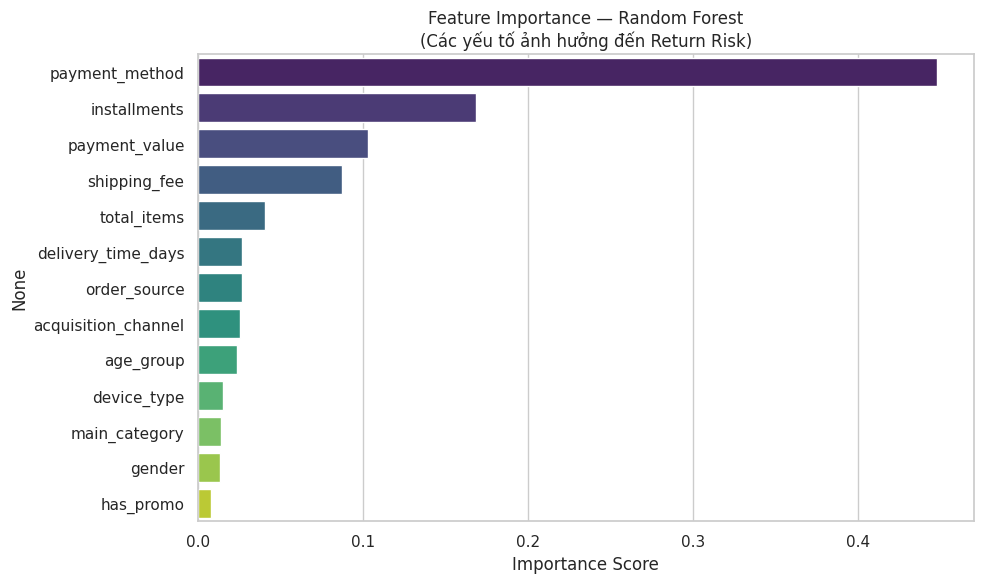


Top 5 yếu tố dự báo return quan trọng nhất:
  1. payment_method: 0.4478
  2. installments: 0.1683
  3. payment_value: 0.1031
  4. shipping_fee: 0.0871
  5. total_items: 0.0405


In [22]:
# ── 6. Feature Importance (Random Forest) ─────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance — Random Forest\n(Các yếu tố ảnh hưởng đến Return Risk)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 yếu tố dự báo return quan trọng nhất:")
for rank, (feat_name, score) in enumerate(feat_imp.head(5).items(), 1):
    print(f"  {rank}. {feat_name}: {score:.4f}")

### Phân bố Return Risk Score theo Age Group và Category
Risk score trung bình theo phân khúc giúp xác định nhóm khách hàng cần can thiệp sớm.

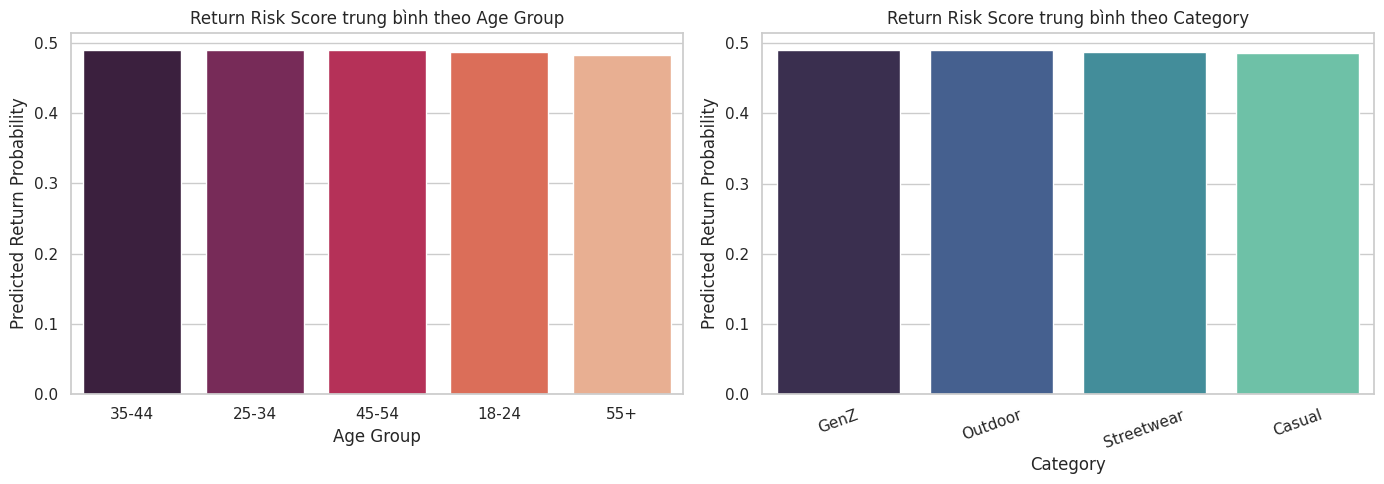


Phân khúc rủi ro cao nhất (Age Group x Category):
age_group_label category_label  return_prob
          25-34           GenZ     0.491897
          35-44           GenZ     0.491024
          35-44        Outdoor     0.490738
          25-34        Outdoor     0.490660
          45-54           GenZ     0.490499


In [23]:
# ── 7. Phân bố Return-Risk Score theo Age Group & Category ───────────────────
feat_scored = feat.copy().dropna(subset=cat_cols + num_cols)
for col in cat_cols:
    feat_scored[col] = le_dict[col].transform(feat_scored[col].astype(str))

feat_scored['return_prob'] = rf.predict_proba(feat_scored[cat_cols + num_cols])[:, 1]

# Decode lại age_group để vẽ
feat_scored['age_group_label'] = le_dict['age_group'].inverse_transform(feat_scored['age_group'])
feat_scored['category_label']  = le_dict['main_category'].inverse_transform(feat_scored['main_category'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk score trung bình theo age group
age_risk = feat_scored.groupby('age_group_label')['return_prob'].mean().sort_values(ascending=False)
sns.barplot(x=age_risk.index, y=age_risk.values, palette='rocket', ax=axes[0])
axes[0].set_title('Return Risk Score trung bình theo Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Predicted Return Probability')

# Risk score theo category
cat_risk = feat_scored.groupby('category_label')['return_prob'].mean().sort_values(ascending=False)
sns.barplot(x=cat_risk.index, y=cat_risk.values, palette='mako', ax=axes[1])
axes[1].set_title('Return Risk Score trung bình theo Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Predicted Return Probability')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print("\nPhân khúc rủi ro cao nhất (Age Group x Category):")
risk_seg = (feat_scored.groupby(['age_group_label', 'category_label'])['return_prob']
            .mean().reset_index()
            .sort_values('return_prob', ascending=False)
            .head(5))
print(risk_seg.to_string(index=False))

---
## PRESCRIPTIVE ANALYTICS — Kế hoạch hành động ưu tiên

> **Bối cảnh:** 646,945 đơn hàng | Return rate tổng: **5.6%** (36,062 đơn) | Rating TB: **3.94/5.0**
>
> **5 lý do return:** wrong_size **34.97%** · defective **20.08%** · not_as_described **17.61%** · changed_mind **17.35%** · late_delivery **9.98%**

---

### 1. Giảm Return do **Wrong Size** — lý do hàng đầu (35% tổng return)

| Ưu tiên | Hành động cụ thể | Mục tiêu | Tác động dự kiến |
|---|---|---|---|
| **P1** | Làm mới bảng size Streetwear với hướng dẫn đo + ảnh thực tế (XL: 6,378 · S: 5,094 wrong-size returns) | Streetwear · 25–44 tuổi | Giảm 15–20% wrong-size Streetwear |
| **P1** | Thêm size guide pop-up tại bước chọn size trên app/web cho Outdoor (L: 3,937 · M: 3,706) | Outdoor · 25–54 tuổi | Giảm ~10% wrong-size Outdoor |
| **P2** | Hiển thị "khách hàng hay chọn size nào" dựa trên lịch sử mua theo chiều cao/cân nặng | Tất cả categories | Giảm tỉ lệ đặt sai size |
| **P3** | Ưu tiên đẩy review UGC có đề cập fit/size thực tế lên đầu trang sản phẩm | GenZ · 18–24 tuổi | Tăng confidence trước khi mua |

**Lưu ý:** Casual (1,243) và GenZ category (2,098) có wrong-size thấp hơn đáng kể — không cần ưu tiên cao.

---

### 2. Kiểm soát Chất lượng — **Defective** (20% tổng return)

| Ưu tiên | Hành động | Category | Quy mô vấn đề |
|---|---|---|---|
| **P1** | Audit toàn bộ quy trình QC đầu vào + đóng gói cho Streetwear | Streetwear | 12,028 defective returns |
| **P1** | Review quy trình kiểm tra và bảo quản hàng Outdoor (nhiệt độ, độ ẩm) | Outdoor | 8,351 defective returns |
| **P2** | Bổ sung kiểm tra mẫu ngẫu nhiên (sampling) 5% trước khi xuất kho | Tất cả | Ngăn chặn sớm hàng lỗi |
| **P3** | Đối chiếu lô hàng lỗi với thời điểm nhập kho và nhà cung cấp để truy nguồn | Streetwear + Outdoor | Xử lý gốc rễ |

---

### 3. Can thiệp **COD Payment** — rủi ro return cao nhất *(phát hiện mới)*

> COD chiếm **14.9% đơn hàng** nhưng return rate **8.90%** — cao hơn **78%** so với các phương thức khác (~5%). Nhóm 35–44 tuổi dùng COD có return rate cao nhất: **9.31%**.

| Ưu tiên | Hành động |
|---|---|
| **P1** | Gọi điện/gửi OTP xác nhận đơn cho 100% đơn COD có giá trị > ngưỡng trung bình |
| **P1** | Hiển thị cảnh báo nhẹ "Vui lòng kiểm tra kỹ trước khi đặt hàng COD" trên trang checkout |
| **P2** | Áp dụng giới hạn số lượng sản phẩm per-order với đơn COD (giảm impulse buy) |
| **P3** | Xây dựng chương trình khuyến khích chuyển sang thanh toán online (voucher nhỏ) |

---

### 4. Cải thiện mô tả sản phẩm — **Not As Described** (17.6% tổng return)

> Streetwear: 10,696 · Outdoor: 7,061 · GenZ: 1,030 · Casual: 571

- **P1:** Audit trang sản phẩm Streetwear và Outdoor — so sánh mô tả/ảnh với phản hồi thực tế từ review.
- **P2:** Chuẩn hóa template mô tả sản phẩm: chất liệu, màu sắc thực, size model mặc kèm chiều cao/cân nặng.
- **P3:** Thêm video 360° cho top 50 sản phẩm có not_as_described cao nhất.

---

### 5. Tối ưu **Vận chuyển** — late delivery 10% tổng return

> Thời gian giao hàng TB: **4.5 ngày** (median 4 ngày). **29.1% đơn giao > 5 ngày**. Đơn 5 sao có median delivery **4 ngày** vs 5 ngày cho 1–4 sao.

- **P1:** Thiết lập cảnh báo SLA nội bộ khi dự kiến giao > 5 ngày → chủ động thông báo cho khách và offer voucher bù đắp.
- **P2:** Phân tích các tuyến vận chuyển có delivery > 6 ngày để đàm phán lại SLA với đối tác logistics.
- **P3:** Gửi email/push thông báo tracking thực thời gian thực khi đơn chậm trễ > 1 ngày so với cam kết.

---

### 6. Khai thác Return Risk Model *(Predictive → Prescriptive)*

> **Giới hạn mô hình:** Random Forest ROC-AUC = **0.5595**, Logistic Regression = **0.5432** — cả hai gần như tương đương random (0.5). Mô hình hiện tại **chưa đủ tin cậy** để scoring đơn lẻ.
>
> **Nguyên nhân:** Feature importance cho thấy `payment_method` chiếm **44.78%** — mô hình đang học chủ yếu từ COD vs non-COD, không từ hành vi mua thực sự. Cần thêm features hành vi (lịch sử return của khách, tần suất đặt hàng, khoảng cách size so với lần mua trước).

**Chiến lược ngắn hạn — Rule-based thay thế model:**

| Điều kiện | Hành động | Lý do |
|---|---|---|
| COD + Streetwear/Outdoor | Gọi xác nhận trước giao hàng | Return rate 8.9% + wrong_size/defective cao |
| COD + payment_value > P75 | Xác nhận 2 bước trên app | Giá trị cao + rủi ro COD |
| Khách có ≥ 2 lần return trong 6 tháng | Thêm bước xác nhận + gợi ý đổi size | Hành vi tái phát |

**Chiến lược dài hạn — Cải thiện model:**

```
Feature mới cần thu thập:
  - Lịch sử return của từng khách (return_rate_30d, return_rate_90d)
  - Số lần mua trùng category/size
  - Khoảng thời gian từ lần return gần nhất
  - Nguồn traffic (trực tiếp vs quảng cáo vs referral)
  - Thời gian từ khi đặt đến khi xác nhận (impulse purchase proxy)

Target AUC tối thiểu để triển khai: 0.65
Tần suất retrain: mỗi quý, hoặc khi drift > 5% return rate thực tế
```

**Phân khúc rủi ro cao nhất** (theo dự báo model hiện tại):
- 25–34 tuổi × GenZ category: prob **0.49**
- 35–44 tuổi × GenZ category: prob **0.49**
- 35–44 tuổi × Outdoor: prob **0.49**

---

### 7. Dashboard theo dõi KPI *(Baseline thực tế)*

| KPI | Baseline hiện tại | Target 6 tháng | Hành động chính |
|---|---|---|---|
| Return rate tổng | **5.6%** | **≤ 3.0%** | Tất cả can thiệp trên |
| Wrong-size return (Streetwear) | 20,744 units | Giảm 20% | Size guide P1 |
| Defective return (Streetwear + Outdoor) | 20,379 units | Giảm 20% | QC audit P1 |
| COD return rate | **8.90%** | **≤ 6.5%** | COD confirmation flow |
| Late delivery return | 10,768 units | Giảm 25% | SLA alert + logistics re-negotiation |
| Rating trung bình | **3.94 / 5.0** | **≥ 4.2 / 5.0** | Giảm defective + cải thiện mô tả |
| Tỉ lệ đơn giao > 5 ngày | **29.1%** | **≤ 20%** | Tối ưu logistics tuyến chậm |

> **Theo dõi:** Dashboard cập nhật hàng tuần. Cảnh báo tự động khi return rate tổng vượt 6% hoặc COD return rate vượt 10%.